In [5]:
"""
BIFURCATION DIAGRAM - 
Demonstrate how the autapse leads to different behaviours in a neuron slightly above threshold.


"""

'\nBIFURCATION DIAGRAM - \nDemonstrate how the autapse leads to different behaviours in a neuron slightly above threshold.\n\n\n'

In [6]:
import sys
sys.path.append("../") # parent directory

import aqua
from aqua.AQUA_general import AQUA
from aqua.batchAQUA_general import batchAQUA
from aqua.stimulus import *
from aqua.plotting_functions import *
from phase_response import *


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# regular spiking neuron
RS_int = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 0.0, 'tau': 2.0}


T = 4  #ms
dt = 0.1 # ms
N_iter = int(1000*T/dt)

x_ini = np.array([-60, 0, 0])
t_ini = 0.0

N_neurons = 400
f_range = np.linspace(0, 500, N_neurons)

#define initial conditions
params_int = []
x_start = np.zeros((N_neurons, 3))
t_start = np.zeros(N_neurons)

for n, f in enumerate(f_range):
    temp_params = RS_int.copy()
    temp_params['f'] = f
    params_int.append(temp_params)
    x_start[n, :] = x_ini
    t_start[n] = t_ini

I = 60
I_inj = np.array([I*np.ones(N_iter) for _ in f_range])

batch_int = batchAQUA(params_int)
batch_int.Initialise(x_start, t_start)
X_int, _, spikes_int = batch_int.update_batch(dt, N_iter, I_inj)


100%|██████████| 39999/39999 [00:06<00:00, 5844.66it/s]


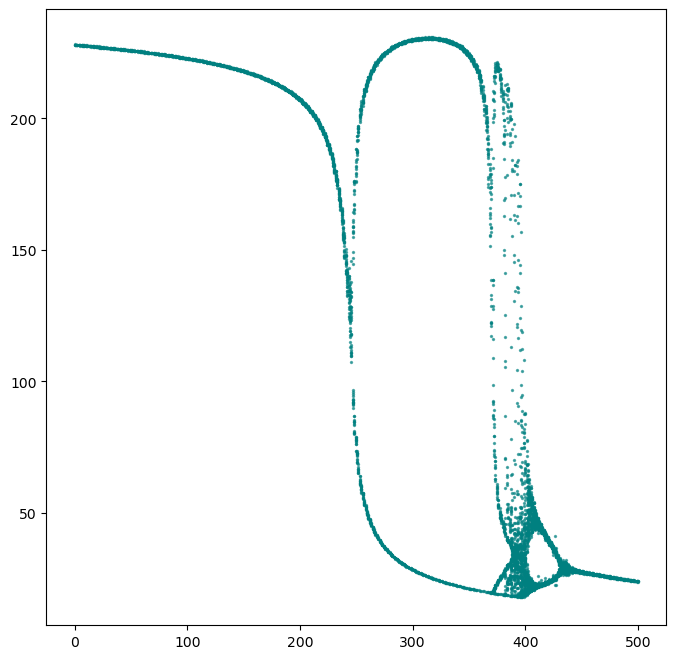

In [11]:
# plot the bifurcation diagram
fig, ax = plt.subplots(1, 1, figsize = (8, 8))
fig, ax = plot_bifurcation(spikes_int, f_range, burn_in = 500, fig = fig, ax = ax)

plt.savefig(f"./behaviours_plots/{RS_int['name']}_bifurcation.svg")
